# MILP Course Scheduling — Solution

**Complete reference solution** for the practice notebook.
All hard constraints, the objective, the soft extension, and the visualisation
are fully implemented using Pyomo.


In [13]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import pyomo.environ as pyo

plt.rcParams.update({"figure.dpi": 110, "font.size": 11})
sns.set_theme(style="whitegrid")
print("Libraries loaded.")


Libraries loaded.


In [14]:
DATA = "data_teaching"

courses   = pd.read_csv(f"{DATA}/courses.csv")
rooms     = pd.read_csv(f"{DATA}/rooms.csv")
timeslots = pd.read_csv(f"{DATA}/timeslots.csv")
lecturers = pd.read_csv(f"{DATA}/lecturers.csv")
conflicts = pd.read_csv(f"{DATA}/course_conflicts.csv")
options   = pd.read_csv(f"{DATA}/course_period_options.csv")

print("Data loaded.")
for name, df in [("courses", courses), ("rooms", rooms), ("timeslots", timeslots),
                 ("conflicts", conflicts), ("options", options)]:
    print(f"  {name:<12} {df.shape}")


Data loaded.
  courses      (10, 6)
  rooms        (5, 4)
  timeslots    (15, 5)
  conflicts    (8, 3)
  options      (6, 2)


In [15]:
C = list(courses["course_id"].astype(int))
T = list(timeslots["timeslot_id"].astype(int))
R = list(rooms["room_id"].astype(int))

room_cap    = dict(zip(rooms["room_id"].astype(int),      rooms["capacity"]))
room_cost   = dict(zip(rooms["room_id"].astype(int),      rooms["cost_per_slot"]))
room_name   = dict(zip(rooms["room_id"].astype(int),      rooms["name"]))
course_cap  = dict(zip(courses["course_id"].astype(int),  courses["capacity_needed"]))
course_stud = dict(zip(courses["course_id"].astype(int),  courses["n_students"]))
course_name = dict(zip(courses["course_id"].astype(int),  courses["name"]))
course_pref = dict(zip(courses["course_id"].astype(int),  courses["preferred_period"]))
slot_cost   = dict(zip(timeslots["timeslot_id"].astype(int), timeslots["cost"]))
slot_period = dict(zip(timeslots["timeslot_id"].astype(int), timeslots["period"]))
slot_day    = dict(zip(timeslots["timeslot_id"].astype(int), timeslots["day"]))

conflict_pairs = [(int(row["course_a"]), int(row["course_b"]))
                  for _, row in conflicts.iterrows()]

lecturer_pairs = []
for _, grp in courses.groupby("lecturer_id"):
    ids = list(grp["course_id"].astype(int))
    for i in range(len(ids)):
        for j in range(i + 1, len(ids)):
            lecturer_pairs.append((ids[i], ids[j]))

allowed_periods = {}
for cid in options["course_id"].unique():
    cid_int = int(cid)
    allowed_periods[cid_int] = set(options[options["course_id"] == cid]["period"])
restricted_courses = list(allowed_periods.keys())

print(f"|C|={len(C)}  |T|={len(T)}  |R|={len(R)}")
print(f"conflict_pairs={len(conflict_pairs)}  lecturer_pairs={len(lecturer_pairs)}")
print(f"restricted_courses={restricted_courses}")


|C|=10  |T|=15  |R|=5
conflict_pairs=8  lecturer_pairs=2
restricted_courses=[6, 10]


---
## Part 1 — Decision Variables


In [16]:
model = pyo.ConcreteModel("CourseScheduling")

model.C = pyo.Set(initialize=C)
model.T = pyo.Set(initialize=T)
model.R = pyo.Set(initialize=R)

model.x = pyo.Var(model.C, model.T, model.R, domain=pyo.Binary)

print(f"Variables: {len(C)*len(T)*len(R)} binary  x[course, timeslot, room]")


Variables: 750 binary  x[course, timeslot, room]


---
## Part 2 — Hard Constraints


In [17]:
# C1: Each course is assigned exactly once
# sum_{t,r} x[c,t,r] = 1   for all c
def c1_rule(m, c):
    return sum(m.x[c, t, r] for t in m.T for r in m.R) == 1

model.C1 = pyo.Constraint(model.C, rule=c1_rule)
print(f"C1: {len(list(model.C1))} constraints")


C1: 10 constraints


In [18]:
# C2: No two courses share the same (timeslot, room)
# sum_c x[c,t,r] <= 1   for all t, r
def c2_rule(m, t, r):
    return sum(m.x[c, t, r] for c in m.C) <= 1

model.C2 = pyo.Constraint(model.T, model.R, rule=c2_rule)
print(f"C2: {len(list(model.C2))} constraints")


C2: 75 constraints


In [19]:
# C3: Room capacity >= class size
# x[c,t,r] = 0  when room_cap[r] < course_cap[c]
def c3_rule(m, c, t, r):
    if room_cap[r] < course_cap[c]:
        return m.x[c, t, r] == 0
    return pyo.Constraint.Skip

model.C3 = pyo.Constraint(model.C, model.T, model.R, rule=c3_rule)
n_fixed = sum(1 for _ in model.C3)
print(f"C3: {n_fixed} infeasible (c,t,r) triples fixed to 0")


C3: 225 infeasible (c,t,r) triples fixed to 0


In [20]:
# C4: Courses sharing students cannot be at the same timeslot
# sum_r x[c1,t,r] + sum_r x[c2,t,r] <= 1   for all (c1,c2) in E, all t
model.C4 = pyo.ConstraintList()
for c1, c2 in conflict_pairs:
    for t in T:
        model.C4.add(
            sum(model.x[c1, t, r] for r in R)
            + sum(model.x[c2, t, r] for r in R) <= 1
        )
print(f"C4: {sum(1 for _ in model.C4)} constraints")


C4: 120 constraints


In [21]:
# C5: A lecturer cannot teach two courses at the same timeslot
# sum_r x[c1,t,r] + sum_r x[c2,t,r] <= 1   for all lecturer pairs, all t
model.C5 = pyo.ConstraintList()
for c1, c2 in lecturer_pairs:
    for t in T:
        model.C5.add(
            sum(model.x[c1, t, r] for r in R)
            + sum(model.x[c2, t, r] for r in R) <= 1
        )
print(f"C5: {sum(1 for _ in model.C5)} constraints")


C5: 30 constraints


In [22]:
# C6: Period restrictions for courses 6 and 10
# x[c,t,r] = 0  if period(t) not in allowed_periods[c]
model.C6 = pyo.ConstraintList()
for c in restricted_courses:
    for t in T:
        if slot_period[t] not in allowed_periods[c]:
            for r in R:
                model.C6.add(model.x[c, t, r] == 0)
print(f"C6: {sum(1 for _ in model.C6)} variables fixed to 0")


C6: 60 variables fixed to 0


---
## Part 3 — Objective Function

$$\min \sum_{c,t,r} \bigl(\text{rc}[r] + \text{tc}[t]\bigr) \cdot x_{c,t,r}$$


In [23]:
def obj_rule(m):
    return sum(
        (room_cost[r] + slot_cost[t]) * m.x[c, t, r]
        for c in m.C for t in m.T for r in m.R
    )

model.obj = pyo.Objective(rule=obj_rule, sense=pyo.minimize)
print("Objective set.")


Objective set.


---
## Part 4 — Solve and Display Results


In [24]:
solver = pyo.SolverFactory("appsi_highs")

if not solver.available():
    raise RuntimeError("Solver not found. Install HiGHS: pip install highspy")

result = solver.solve(model, tee=False)

is_optimal = result.solver.termination_condition == pyo.TerminationCondition.optimal
print(f"Status : {'Optimal' if is_optimal else result.solver.termination_condition}")

if not is_optimal:
    raise RuntimeError("Solver did not find an optimal solution.")

print(f"Optimal cost : {pyo.value(model.obj):.0f}")

rows = []
for c in C:
    for t in T:
        for r in R:
            val = pyo.value(model.x[c, t, r])
            if val is not None and val > 0.5:
                rows.append({
                    "course_id"  : c,
                    "course"     : course_name[c],
                    "day"        : slot_day[t],
                    "period"     : slot_period[t],
                    "timeslot_id": t,
                    "room_id"    : r,
                    "room"       : room_name[r],
                    "enrolled"   : course_stud[c],
                    "capacity"   : room_cap[r],
                    "cost"       : room_cost[r] + slot_cost[t],
                })

day_order    = ["Mon", "Tue", "Wed"]
period_order = ["P1", "P2", "P3", "P4", "P5"]
sol = pd.DataFrame(rows)
sol["day"]    = sol["day"].astype(pd.CategoricalDtype(day_order, ordered=True))
sol["period"] = sol["period"].astype(pd.CategoricalDtype(period_order, ordered=True))
sol = sol.sort_values(["day", "period"]).reset_index(drop=True)
print(f"Assignments : {len(sol)}")


Status : Optimal
Optimal cost : 35
Assignments : 10


In [25]:
display(sol[["course", "day", "period", "room", "enrolled", "capacity", "cost"]])

print()
print("Schedule pivot (course / room):")
sol["entry"] = sol["course"].str[:10] + " / " + sol["room"].str[:6]
pivot = (
    sol.groupby(["period", "day"])["entry"]
       .apply(lambda s: "  |  ".join(s))
       .unstack("day")
       .reindex(columns=["Mon", "Tue", "Wed"])
)
print(pivot.to_string())
print()
total = sol["cost"].sum()
print(f"Total cost: {total}")


,course,day,period,room,enrolled,capacity,cost
0,Programming 101,Mon,P2,Hall B,40,40,5
1,Networks,Mon,P3,Room D,25,25,3
2,Statistics,Mon,P3,Room E,15,20,2
3,AI Fundamentals,Tue,P2,Room C,30,30,4
4,OS Concepts,Tue,P2,Room E,20,20,2
5,Databases,Tue,P3,Room E,18,20,2
6,ML Basics,Tue,P3,Hall B,35,40,5
7,Math Analysis,Wed,P2,Hall B,35,40,5
8,Linear Algebra,Wed,P3,Room C,28,30,4
9,Data Structures,Wed,P3,Room D,22,25,3



Schedule pivot (course / room):
day                                           Mon                                          Tue                                          Wed
period                                                                                                                                     
P2                            Programmin / Hall B  AI Fundame / Room C  |  OS Concept / Room E                          Math Analy / Hall B
P3      Networks / Room D  |  Statistics / Room E    Databases / Room E  |  ML Basics / Hall B  Linear Alg / Room C  |  Data Struc / Room D

Total cost: 35


---
## Part 5 — Soft Constraints Extension

$$\min \sum_{c,t,r} \bigl(\text{rc}[r] + \text{tc}[t] + \lambda \cdot \text{pen}_{c,t}\bigr) \cdot x_{c,t,r}$$

where $\text{pen}_{c,t} = 1$ if $\text{period}(t) \neq \text{preferred\_period}(c)$.


In [26]:
pen = {(c, t): 0 if slot_period[t] == course_pref[c] else 1
       for c in C for t in T}

lam = 2   # try 0, 1, 2, 5

model_soft = pyo.ConcreteModel("CourseScheduling_soft")
model_soft.C = pyo.Set(initialize=C)
model_soft.T = pyo.Set(initialize=T)
model_soft.R = pyo.Set(initialize=R)
model_soft.x = pyo.Var(model_soft.C, model_soft.T, model_soft.R, domain=pyo.Binary)

# Hard constraints (identical to the base model)
def c1s(m, c):      return sum(m.x[c, t, r] for t in m.T for r in m.R) == 1
def c2s(m, t, r):   return sum(m.x[c, t, r] for c in m.C) <= 1
def c3s(m, c, t, r):
    if room_cap[r] < course_cap[c]: return m.x[c, t, r] == 0
    return pyo.Constraint.Skip

model_soft.C1 = pyo.Constraint(model_soft.C, rule=c1s)
model_soft.C2 = pyo.Constraint(model_soft.T, model_soft.R, rule=c2s)
model_soft.C3 = pyo.Constraint(model_soft.C, model_soft.T, model_soft.R, rule=c3s)

model_soft.C4 = pyo.ConstraintList()
for c1, c2 in conflict_pairs:
    for t in T:
        model_soft.C4.add(
            sum(model_soft.x[c1, t, r] for r in R)
            + sum(model_soft.x[c2, t, r] for r in R) <= 1)

model_soft.C5 = pyo.ConstraintList()
for c1, c2 in lecturer_pairs:
    for t in T:
        model_soft.C5.add(
            sum(model_soft.x[c1, t, r] for r in R)
            + sum(model_soft.x[c2, t, r] for r in R) <= 1)

model_soft.C6 = pyo.ConstraintList()
for c in restricted_courses:
    for t in T:
        if slot_period[t] not in allowed_periods[c]:
            for r in R:
                model_soft.C6.add(model_soft.x[c, t, r] == 0)

# Soft objective
def soft_obj_rule(m):
    return sum(
        (room_cost[r] + slot_cost[t] + lam * pen[(c, t)]) * m.x[c, t, r]
        for c in m.C for t in m.T for r in m.R
    )

model_soft.obj = pyo.Objective(rule=soft_obj_rule, sense=pyo.minimize)

# Solve
result_soft = solver.solve(model_soft, tee=False)
ok_soft = result_soft.solver.termination_condition == pyo.TerminationCondition.optimal
print(f"Soft status   : {'Optimal' if ok_soft else result_soft.solver.termination_condition}")
if ok_soft:
    print(f"Soft objective: {pyo.value(model_soft.obj):.0f}  (lambda={lam})")
    pref_met = sum(
        1 for c in C for t in T for r in R
        if pyo.value(model_soft.x[c, t, r]) is not None
        and pyo.value(model_soft.x[c, t, r]) > 0.5
        and slot_period[t] == course_pref[c]
    )
    print(f"Preferences met: {pref_met} / {len(C)} courses")

    # Compare base vs soft schedule
    print()
    print("Differences  (base -> soft):")
    base_assign = {c: (slot_day[t], slot_period[t], room_name[r])
                   for c in C for t in T for r in R
                   if pyo.value(model.x[c, t, r]) is not None
                   and pyo.value(model.x[c, t, r]) > 0.5}
    soft_assign = {c: (slot_day[t], slot_period[t], room_name[r])
                   for c in C for t in T for r in R
                   if pyo.value(model_soft.x[c, t, r]) is not None
                   and pyo.value(model_soft.x[c, t, r]) > 0.5}
    changed = {c for c in C if base_assign[c] != soft_assign[c]}
    if changed:
        for c in sorted(changed):
            print(f"  {course_name[c]:<20} {base_assign[c]} -> {soft_assign[c]}")
    else:
        print("  No changes (lambda too small to move any course).")


Soft status   : Optimal
Soft objective: 37  (lambda=2)
Preferences met: 10 / 10 courses

Differences  (base -> soft):
  Linear Algebra       ('Wed', 'P3', 'Room C') -> ('Tue', 'P2', 'Room C')
  Programming 101      ('Mon', 'P2', 'Hall B') -> ('Mon', 'P1', 'Hall B')
  AI Fundamentals      ('Tue', 'P2', 'Room C') -> ('Mon', 'P2', 'Room C')
  Databases            ('Tue', 'P3', 'Room E') -> ('Mon', 'P4', 'Room E')
  OS Concepts          ('Tue', 'P2', 'Room E') -> ('Tue', 'P3', 'Room E')
  ML Basics            ('Tue', 'P3', 'Hall B') -> ('Tue', 'P2', 'Hall B')


---
## Part 6 — Visualisation


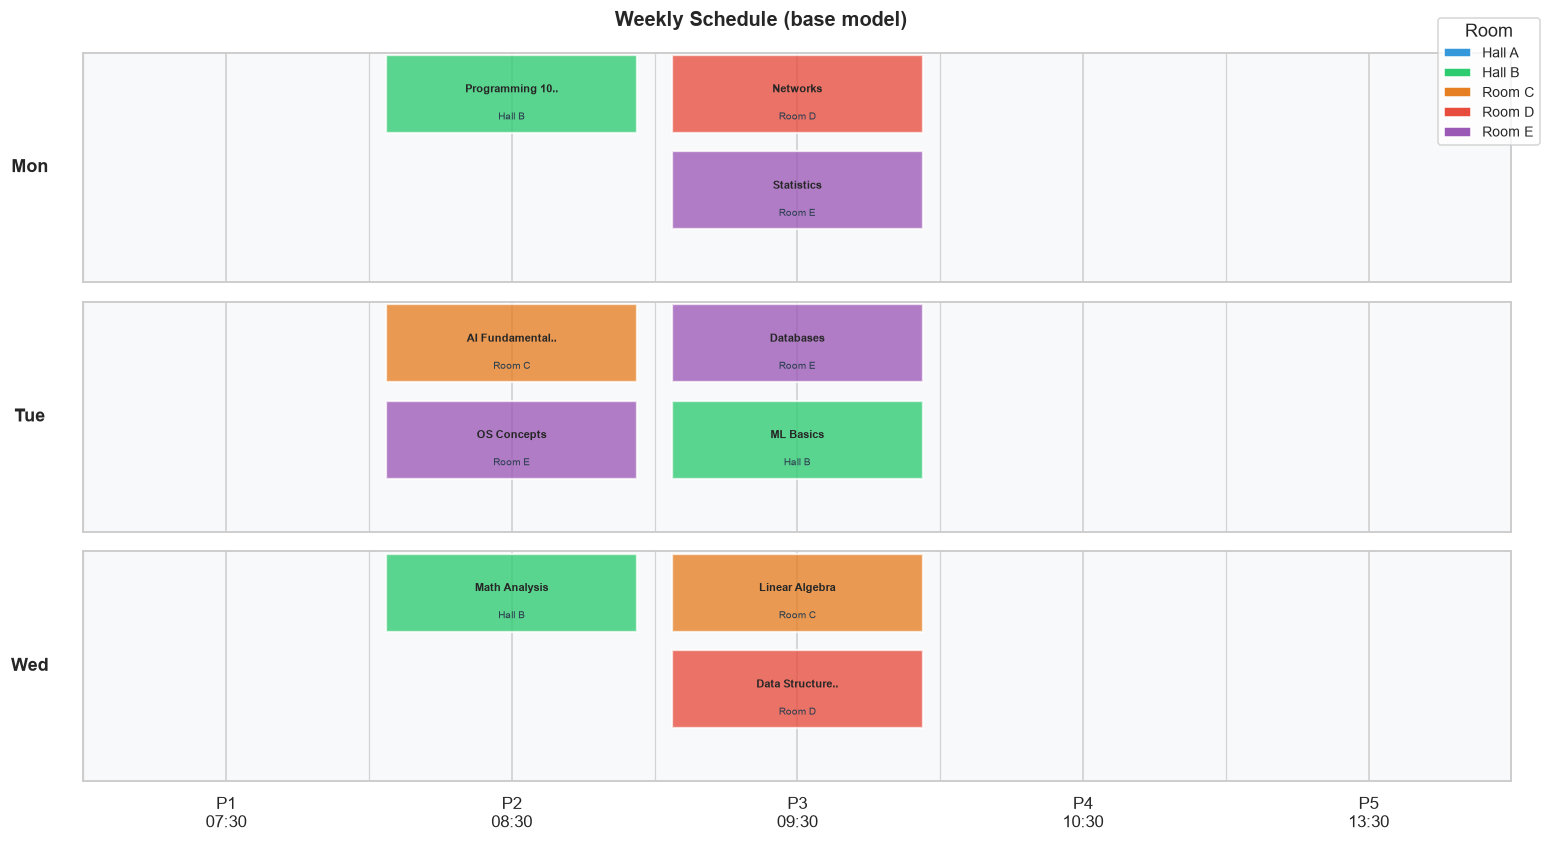

In [27]:
# Build schedule dict from solution
schedule = {}
for c in C:
    for t in T:
        for r in R:
            val = pyo.value(model.x[c, t, r])
            if val is not None and val > 0.5:
                key = (slot_day[t], slot_period[t])
                if key not in schedule:
                    schedule[key] = []
                schedule[key].append((course_name[c], room_name[r], r))

# Draw weekly schedule grid
days    = ["Mon", "Tue", "Wed"]
periods = ["P1", "P2", "P3", "P4", "P5"]
pt_lbl  = ["07:30", "08:30", "09:30", "10:30", "13:30"]
palette  = ["#3498db", "#2ecc71", "#e67e22", "#e74c3c", "#9b59b6"]
room_clr = dict(zip(R, palette))

fig, axes = plt.subplots(len(days), 1, figsize=(14, 2.6 * len(days)), sharex=True)
for di, day in enumerate(days):
    ax = axes[di]
    ax.set_xlim(-0.5, len(periods) - 0.5)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_ylabel(day, rotation=0, labelpad=35, va="center", fontweight="bold")
    ax.set_facecolor("#f8f9fa")
    for j in range(len(periods)):
        ax.axvline(j - 0.5, color="lightgray", linewidth=0.8)
    if di == len(days) - 1:
        ax.set_xticks(range(len(periods)))
        ax.set_xticklabels([f"{p}\n{s}" for p, s in zip(periods, pt_lbl)])
    for j, period in enumerate(periods):
        entries = schedule.get((day, period), [])
        for k, (cname, rname, rid) in enumerate(entries):
            color  = room_clr.get(rid, "#bdc3c7")
            y_base = 0.82 - k * 0.42
            ax.add_patch(plt.Rectangle(
                (j - 0.44, y_base - 0.17), 0.88, 0.34,
                facecolor=color, alpha=0.78, edgecolor="white", linewidth=1.5
            ))
            short = cname[:14] + ".." if len(cname) > 14 else cname
            ax.text(j, y_base + 0.02, short,
                    ha="center", va="center", fontsize=7.5, fontweight="bold")
            ax.text(j, y_base - 0.1, rname,
                    ha="center", va="center", fontsize=6.5, color="#2c3e50")

legend_patches = [mpatches.Patch(facecolor=room_clr[r], label=room_name[r],
                                 edgecolor="white") for r in R]
fig.legend(handles=legend_patches, loc="upper right",
           title="Room", fontsize=9, bbox_to_anchor=(1.01, 0.98))
fig.suptitle("Weekly Schedule (base model)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


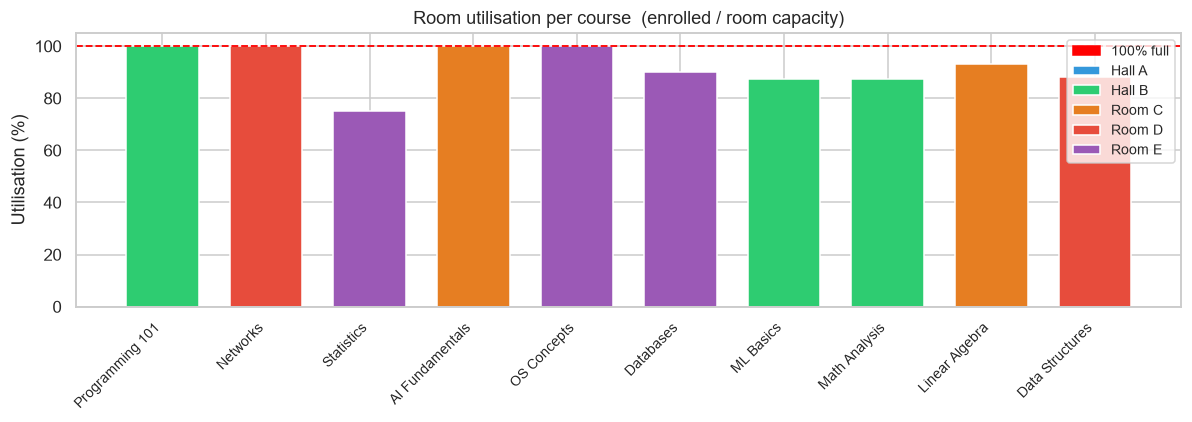

Average utilisation : 92.1%
Total wasted seats  : 22


In [28]:
# Room utilisation chart
palette  = ["#3498db", "#2ecc71", "#e67e22", "#e74c3c", "#9b59b6"]
room_clr = dict(zip(R, palette))
bar_clr  = [room_clr.get(r, "#bdc3c7") for r in sol["room_id"]]
util_pct = (sol["enrolled"] / sol["capacity"] * 100).clip(upper=105)

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(range(len(sol)), util_pct, color=bar_clr, edgecolor="white", width=0.7)
ax.axhline(100, color="red", linestyle="--", linewidth=1.2)
ax.set_xticks(range(len(sol)))
ax.set_xticklabels(sol["course"], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Utilisation (%)")
ax.set_title("Room utilisation per course  (enrolled / room capacity)")
patches = [mpatches.Patch(facecolor=room_clr[r], label=room_name[r]) for r in R]
ax.legend(
    handles=[mpatches.Patch(color="red", label="100% full")] + patches,
    loc="upper right", fontsize=9
)
plt.tight_layout()
plt.show()

avg_util = util_pct.mean()
wasted   = (sol["capacity"] - sol["enrolled"]).sum()
print(f"Average utilisation : {avg_util:.1f}%")
print(f"Total wasted seats  : {wasted}")
